# Shopping Copilot: seven-model intent classification comparison
**CAP-03 · AWS ML Engineering · 7 October 2026**

This notebook presents the completed offline experiment. **Run All reads saved evidence only:** it does not train models, download weights, load pickle files, contact inference providers or execute shopping Actions.

**Important:** 210 training examples, 53 reused validation examples, **zero unseen cases**. All examples are exposed synthetic development data, with AI-reviewed draft labels rather than independent human gold. Model selection used validation; these scores are exploratory and do not measure the live Shopping Copilot.

Sources: [experiment protocol](../docs/cap03-model-comparison-protocol.md), [full report](../docs/cap03-model-comparison-results.md), [frozen data](../eval/datasets/capstone-v1/pilot-20261007/release.json).


In [1]:
import hashlib
import html
import json
from collections import Counter
from pathlib import Path
from IPython.display import HTML, Image, Markdown, display

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "eval/evidence/cap03-comparison-20261007/classical.json").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook inside the shopping-copilot checkout.")
EVIDENCE = ROOT / "eval/evidence/cap03-comparison-20261007"

def read_json(path):
    return json.loads(path.read_text(encoding="utf-8"))

def sha(path):
    return hashlib.sha256(path.read_bytes().replace(b"\r\n", b"\n")).hexdigest()

def table(headers, rows):
    def cell(value):
        return html.escape(str(value))
    header = "".join(f"<th>{cell(h)}</th>" for h in headers)
    body = "".join("<tr>" + "".join(f"<td dir='auto'>{cell(v)}</td>" for v in row) + "</tr>" for row in rows)
    display(HTML("<table style='border-collapse:collapse;text-align:left'><thead><tr>" + header
                 + "</tr></thead><tbody>" + body + "</tbody></table>"))

reports = [read_json(EVIDENCE / name) for name in ("classical.json", "embeddings.json")]
release_path = ROOT / "eval/datasets/capstone-v1/pilot-20261007/release.json"
release = read_json(release_path)
families = [f for report in reports for f in report["families"]]
labels = release["labels"]
names = {
    "lr": "TF-IDF + Logistic Regression", "svm": "TF-IDF + Linear SVM",
    "nb": "TF-IDF + Complement Naive Bayes", "rf": "TF-IDF + Random Forest",
    "xgb": "TF-IDF + XGBoost", "embedding_lr": "Embeddings + Logistic Regression",
    "embedding_mlp": "Embeddings + neural network (MLP)",
}


## 1. Verify the evidence before reading the scores
The checks below bind both reports to the same release, verify pinned source files, and independently recompute selected accuracy and macro-F1 from the recorded predictions. Missing or modified evidence raises an error rather than silently displaying stale results.


In [2]:
validation = [r for r in release["records"] if r["split"] == "validation"]
assert len(validation) == 53 and len(release["records"]) == 263
assert len(families) == 7 and len({f["family"] for f in families}) == 7
assert sum(len(f["trials"]) for f in families) == 46
assert release["unseen_count"] == 0
for report in reports:
    assert report["status"] == "complete" and report["labels"] == labels
    assert report["release_sha256"] == sha(release_path)
    assert report["inference_api_calls"] == 0
    for source, expected in report["source_hashes"].items():
        assert sha(ROOT / source) == expected, source
for source, expected in release["source_hashes"].items():
    assert sha(ROOT / source) == expected, source
for family in families:
    predictions = family["predictions"]
    assert [p["case_id"] for p in predictions] == [r["case_id"] for r in validation]
    assert all(p["text"] == r["text"] and p["label"] == r["label"]
               for p, r in zip(predictions, validation))
    assert all(p["predicted"] in labels for p in predictions)
    correct = sum(p["label"] == p["predicted"] for p in predictions)
    assert all(p["correct"] == (p["label"] == p["predicted"]) for p in predictions)
    f1s = []
    for label in labels:
        tp = sum(p["label"] == label and p["predicted"] == label for p in predictions)
        fp = sum(p["label"] != label and p["predicted"] == label for p in predictions)
        fn = sum(p["label"] == label and p["predicted"] != label for p in predictions)
        f1s.append(2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0)
    assert abs(correct / len(predictions) - family["validation"]["accuracy"]) < 1e-12
    assert abs(sum(f1s) / len(labels) - family["validation"]["macro_f1"]) < 1e-12
print("Verified: same frozen release; source hashes match; all seven selected scores reproduce from predictions.")


Verified: same frozen release; source hashes match; all seven selected scores reproduce from predictions.


## 2. Data and experiment design
The 308 original records yield 263 eligible text-only examples and 45 exclusions. Related turns and paraphrases stay in whole connected components. The model grid was declared before fitting: five TF-IDF classifiers, then two classifier heads sharing a frozen multilingual MiniLM encoder. No encoder fine-tuning occurred.

TF-IDF vocabularies, IDF, feature scaling and classifier parameters were fitted on training only. The 46 candidates had unequal but fixed tuning budgets. Each family's winner was selected by validation macro-F1, then accuracy, then declared candidate index; validation was not used for refitting.


In [3]:
table(["Intent", "Training", "Validation"], [
    [label, reports[0]["counts"]["train"].get(label, 0), reports[0]["counts"]["validation"].get(label, 0)]
    for label in labels
])
table(["Language", "Training", "Validation"], [
    [lang, *[sum(r["language"] == lang and r["split"] == split for r in release["records"])
             for split in ("train", "validation")]]
    for lang in sorted({r["language"] for r in release["records"]})
])


Intent,Training,Validation
advice,29,4
find_products,38,4
locate,15,4
navigate,20,5
open_product,14,4
mutate,20,4
cart_edit,42,4
help,14,4
off_topic,9,8
unsupported,9,12


Language,Training,Validation
egyptian_arabic,51,13
english,53,14
franco_arabic,53,13
mixed,53,13


## 3. Seven-family comparison
Accuracy is the fraction of correct intent labels. Macro-F1 gives equal weight to all ten labels. The difference between the top models is only one or two validation examples; do not interpret the ranking as statistically established superiority.


Model,Correct / 53,Accuracy,Macro-F1,Candidate fits
Embeddings + Logistic Regression,23,43.40%,0.4304,6
Embeddings + neural network (MLP),22,41.51%,0.4189,4
TF-IDF + Complement Naive Bayes,21,39.62%,0.3987,4
TF-IDF + Logistic Regression,20,37.74%,0.3776,12
TF-IDF + Linear SVM,18,33.96%,0.3294,12
TF-IDF + Random Forest,17,32.08%,0.3071,4
TF-IDF + XGBoost,13,24.53%,0.2615,4


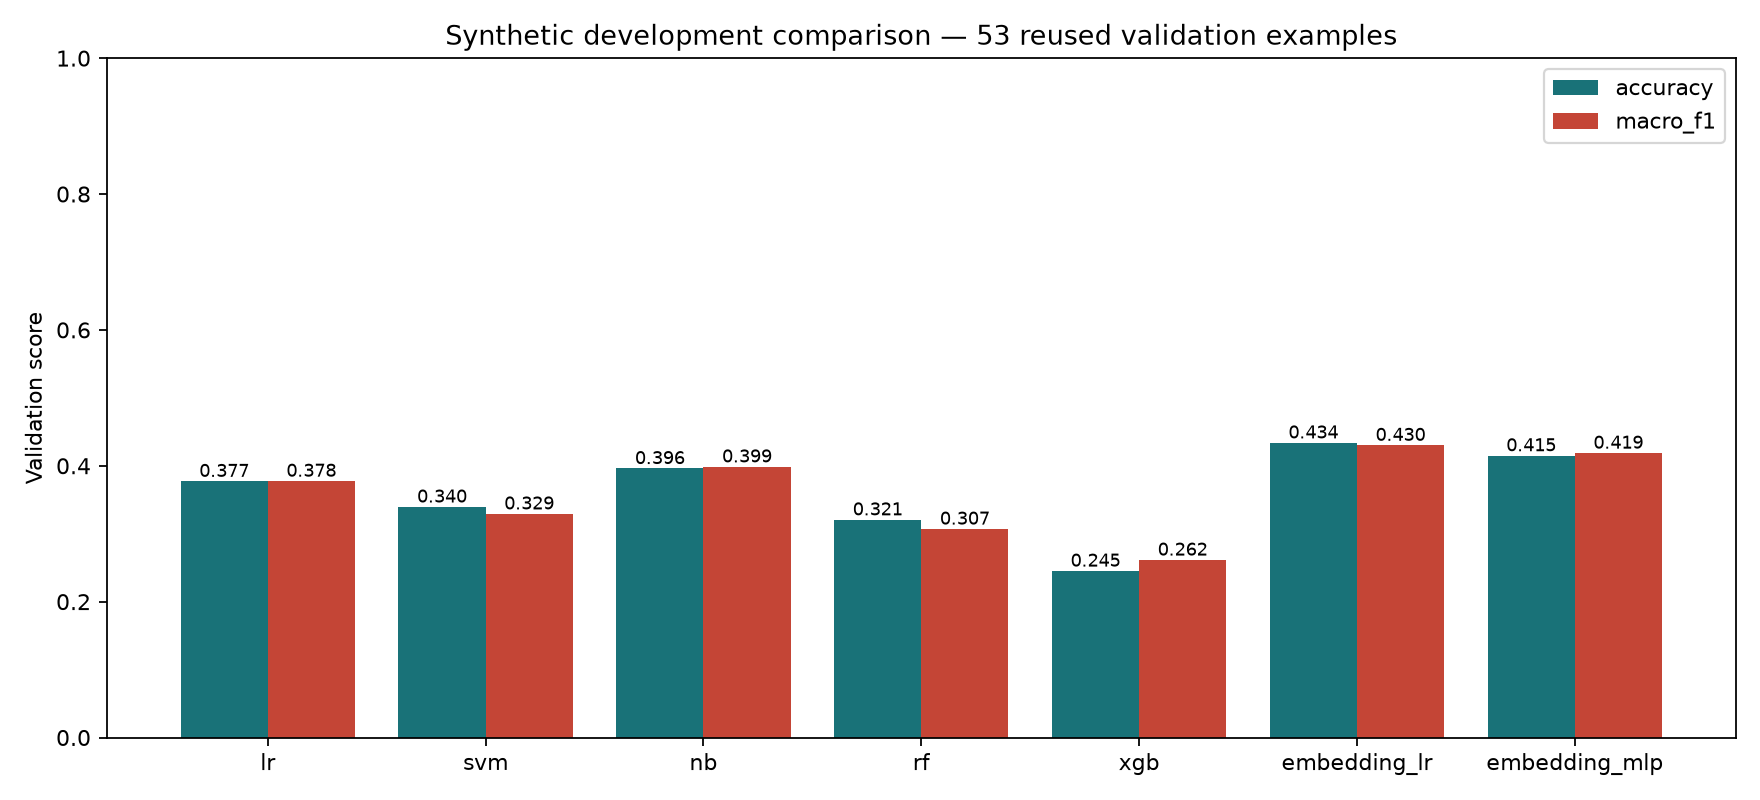

In [4]:
ranked = sorted(families, key=lambda f: -f["validation"]["macro_f1"])
table(["Model", "Correct / 53", "Accuracy", "Macro-F1", "Candidate fits"], [
    [names[f["family"]], sum(p["correct"] for p in f["predictions"]),
     f'{f["validation"]["accuracy"]:.2%}', f'{f["validation"]["macro_f1"]:.4f}', len(f["trials"])]
    for f in ranked
])
display(Image(filename=str(EVIDENCE / "figures/comparison.png"), width=1000))


## 4. Language slices
These small slices have different class compositions. They are descriptive breakdowns, not reliable rankings of language capability. Franco-Arabic remains particularly difficult for the embedding models in this experiment.


In [5]:
languages = ["egyptian_arabic", "franco_arabic", "english", "mixed"]
table(["Model", *[f"{lang} (n={sum(r['language']==lang for r in validation)})" for lang in languages]], [
    [names[f["family"]], *[f'{f["per_language"][lang]["accuracy"]:.2%}' for lang in languages]]
    for f in ranked
])


Model,egyptian_arabic (n=13),franco_arabic (n=13),english (n=14),mixed (n=13)
Embeddings + Logistic Regression,46.15%,23.08%,50.00%,53.85%
Embeddings + neural network (MLP),38.46%,15.38%,71.43%,38.46%
TF-IDF + Complement Naive Bayes,46.15%,23.08%,28.57%,61.54%
TF-IDF + Logistic Regression,38.46%,23.08%,35.71%,53.85%
TF-IDF + Linear SVM,30.77%,15.38%,42.86%,46.15%
TF-IDF + Random Forest,38.46%,15.38%,35.71%,38.46%
TF-IDF + XGBoost,30.77%,15.38%,21.43%,30.77%


## 5. Inspect a model's errors
Change `selected_family` to any key in `names` and rerun the following cells. The default shows the leading embedding Logistic Regression. Arabic text is displayed with automatic direction, and all dataset text is HTML-escaped. These requests are synthetic examples, not participant transcripts.


### Embeddings + Logistic Regression

Intent,Support,Precision,Recall,F1
advice,4,0.750,0.750,0.750
find_products,4,0.364,1.000,0.533
locate,4,0.500,0.250,0.333
navigate,5,0.167,0.200,0.182
open_product,4,0.750,0.750,0.750
mutate,4,0.000,0.000,0.000
cart_edit,4,0.364,1.000,0.533
help,4,0.500,0.500,0.500
off_topic,8,1.000,0.125,0.222
unsupported,12,1.000,0.333,0.500


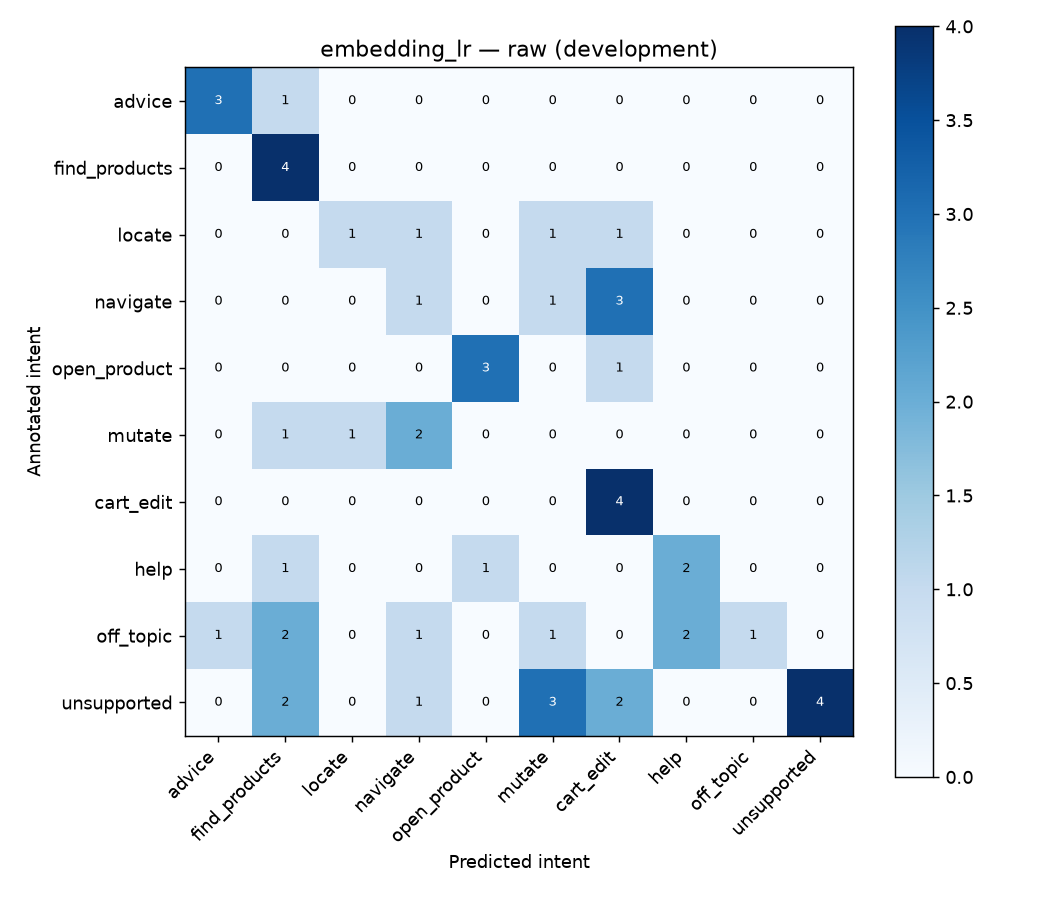

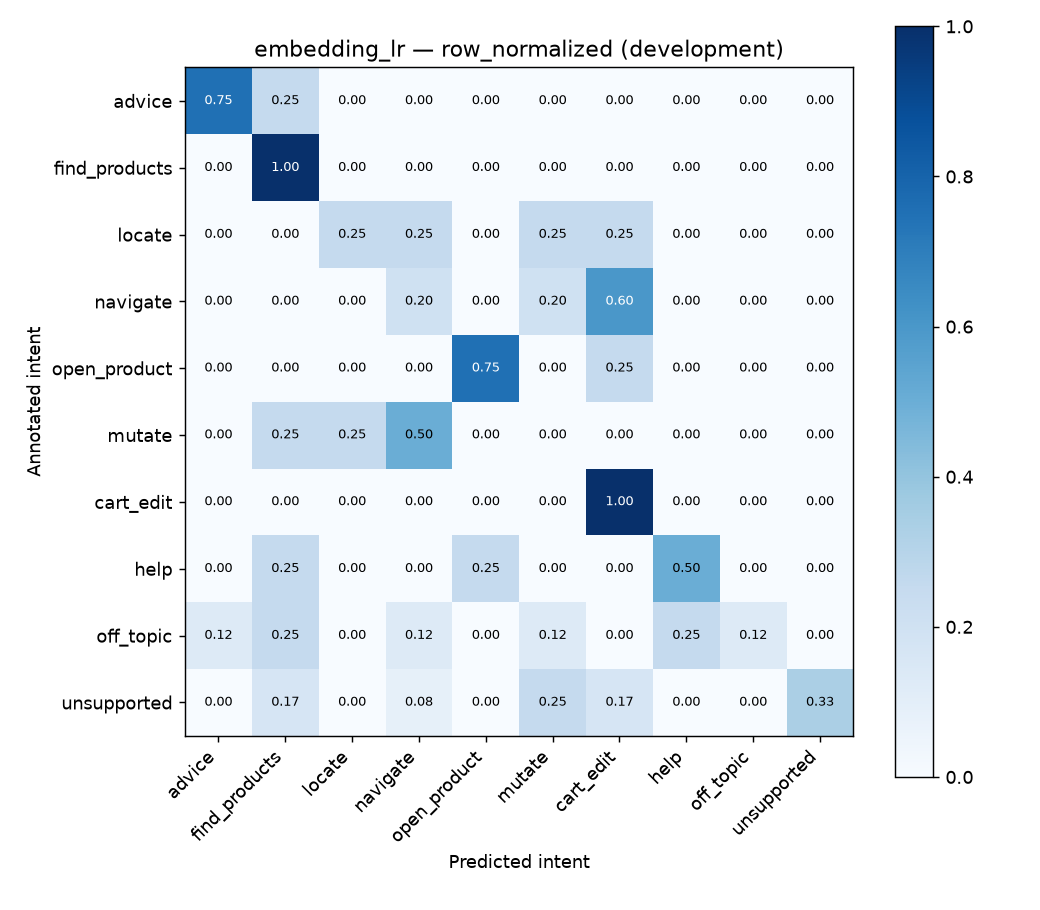

In [6]:
selected_family = "embedding_lr"
selected = next(f for f in families if f["family"] == selected_family)
display(Markdown(f"### {names[selected_family]}"))
table(["Intent", "Support", "Precision", "Recall", "F1"], [
    [label, int(selected["validation"]["classification"][label]["support"]),
     *[f'{selected["validation"]["classification"][label][metric]:.3f}'
       for metric in ("precision", "recall", "f1-score")]]
    for label in labels
])
display(Image(filename=str(EVIDENCE / f"figures/{selected_family}-raw.png"), width=760))
display(Image(filename=str(EVIDENCE / f"figures/{selected_family}-row_normalized.png"), width=760))


In [7]:
errors = [p for p in selected["predictions"] if not p["correct"]]
print(f"All {len(errors)} selected-model errors, in original validation order:")
table(["Case ID", "Language", "Request", "Annotated intent", "Predicted intent"], [
    [p["case_id"], p["language"], p["text"], p["label"], p["predicted"]] for p in errors
])


All 30 selected-model errors, in original validation order:


Case ID,Language,Request,Annotated intent,Predicted intent
syn-en-03,english,"take me to my orders, newest one first if u can",navigate,cart_edit
synthetic-002-015,english,im between M and L on Formal Shirt. what would you need to know before recommending a size?,advice,find_products
synthetic-002-046,franco_arabic,"eshawerly 3ala link 7esaby, bala ma ten2elny",locate,cart_edit
synthetic-002-047,english,where exactly is the account link? just mark it for me,locate,navigate
synthetic-002-048,mixed,الـ account icon مش لاقيه، بس وريني مكانه من غير navigation,locate,mutate
synthetic-002-057,egyptian_arabic,عايز اروح صفحه طلباتي القديمه، مش بطلب حاجه جديده,navigate,mutate
synthetic-002-058,franco_arabic,"wareeny saf7et el orders bta3ty, ana naseet awsalha ezay",navigate,cart_edit
synthetic-002-059,english,can we go back to order history? leave this product for now,navigate,cart_edit
synthetic-002-078,franco_arabic,"men el talat tarshi7at elly odamna, el ar5as efta7 saf7eto bas",open_product,cart_edit
synthetic-002-093,egyptian_arabic,انا دوست شراء ومش فاهم تم ولا لا، جرب تبعت الطلب تاني,mutate,find_products


## 6. Timing and model size
All classifiers used CPU execution limited to four threads. The frozen encoder used an RTX 3060 (12 GiB), PyTorch CUDA 13.0. Thus this is not a matched-hardware speed benchmark.

Embedding latency includes fresh tokenization, GPU encoding, CPU transfer and classification. Shared feature preparation is excluded from classifier fitting time and reported separately. Embedding classifier files also require the shared encoder; their small head size is not the total deployment size. Warm timings exclude one-time downloads and are not end-to-end shopping-task latency. Local compute/electricity cost was not measured.


In [8]:
table(["Model", "Warm p50 ms", "Warm p95 ms", "Selected fit s", "Head/pipeline MiB", "Shared encoder MiB"], [
    [names[f["family"]], f'{f["latency_ms"]["p50"]:.3f}', f'{f["latency_ms"]["p95"]:.3f}',
     f'{next(t for t in f["trials"] if t["config"] == f["selected_config"])["training_seconds"]:.3f}',
     f'{f["artifact_bytes"]/2**20:.3f}', f'{f["shared_encoder_bytes"]/2**20:.1f}']
    for f in ranked
])
encoder_report = reports[1]
table(["Encoder detail", "Recorded value"], [
    ["Model", encoder_report["encoder"]["model"]],
    ["Pinned revision", encoder_report["encoder"]["revision"]],
    ["GPU", encoder_report["encoder"]["gpu_name"]],
    ["CUDA build", encoder_report["encoder"]["cuda_build"]],
    ["Shared embedding preparation seconds", round(encoder_report["embedding_preparation_seconds"], 3)],
    ["Truncated train / validation messages", json.dumps(encoder_report["truncated"])],
])


Model,Warm p50 ms,Warm p95 ms,Selected fit s,Head/pipeline MiB,Shared encoder MiB
Embeddings + Logistic Regression,7.735,9.907,0.073,0.026,471.6
Embeddings + neural network (MLP),8.525,12.128,0.120,0.596,471.6
TF-IDF + Complement Naive Bayes,0.719,0.988,0.017,1.633,0.0
TF-IDF + Logistic Regression,0.486,0.617,0.036,0.867,0.0
TF-IDF + Linear SVM,0.398,0.634,0.008,0.276,0.0
TF-IDF + Random Forest,24.029,24.746,0.218,1.253,0.0
TF-IDF + XGBoost,0.807,1.197,1.980,1.166,0.0


Encoder detail,Recorded value
Model,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Pinned revision,e8f8c211226b894fcb81acc59f3b34ba3efd5f42
GPU,NVIDIA GeForce RTX 3060
CUDA build,13.0
Shared embedding preparation seconds,0.508
Truncated train / validation messages,"{""train"": 0, ""validation"": 0}"


## 7. All trials and reproducibility metadata
Every attempted configuration is retained below, including convergence and failure status. The reports also contain hashes for the local selected model files and embedding arrays. These large artifacts remain outside Git; this notebook intentionally never unpickles them.


In [9]:
table(["Index", "Family", "Configuration", "Converged", "Accuracy", "Macro-F1", "Error"], [
    [t["config"]["index"], t["config"]["family"],
     json.dumps({k:v for k,v in t["config"].items() if k not in ("index", "family")}),
     t.get("converged", False), f'{t.get("accuracy",0):.4f}', f'{t.get("macro_f1",0):.4f}', t.get("error", "")]
    for f in families for t in f["trials"]
])
table(["Phase", "Python", "Platform", "Recorded packages", "Release SHA-256"], [
    [r["phase"], r["environment"]["python"], r["environment"]["platform"],
     json.dumps(r["environment"]["packages"], sort_keys=True), r["release_sha256"]] for r in reports
])


Index,Family,Configuration,Converged,Accuracy,Macro-F1,Error
0,lr,"{""features"": ""word"", ""C"": 0.1, ""class_weight"": null}",True,0.1132,0.0812,
1,lr,"{""features"": ""word"", ""C"": 0.1, ""class_weight"": ""balanced""}",True,0.2830,0.2754,
2,lr,"{""features"": ""word"", ""C"": 1.0, ""class_weight"": null}",True,0.1321,0.0495,
3,lr,"{""features"": ""word"", ""C"": 1.0, ""class_weight"": ""balanced""}",True,0.3396,0.3336,
4,lr,"{""features"": ""word"", ""C"": 10.0, ""class_weight"": null}",True,0.3208,0.3161,
5,lr,"{""features"": ""word"", ""C"": 10.0, ""class_weight"": ""balanced""}",True,0.3396,0.3298,
6,lr,"{""features"": ""char_wb"", ""C"": 0.1, ""class_weight"": null}",True,0.1321,0.0901,
7,lr,"{""features"": ""char_wb"", ""C"": 0.1, ""class_weight"": ""balanced""}",True,0.3774,0.3776,
8,lr,"{""features"": ""char_wb"", ""C"": 1.0, ""class_weight"": null}",True,0.1698,0.1126,
9,lr,"{""features"": ""char_wb"", ""C"": 1.0, ""class_weight"": ""balanced""}",True,0.3208,0.3190,


Phase,Python,Platform,Recorded packages,Release SHA-256
classical,3.12.5,Windows-11-10.0.26300-SP0,"{""huggingface-hub"": ""1.33.0"", ""joblib"": ""1.6.0"", ""numpy"": ""2.5.3"", ""scikit-learn"": ""1.9.1"", ""scipy"": ""1.18.1"", ""sentence-transformers"": ""6.1.0"", ""torch"": ""2.14.1"", ""transformers"": ""5.19.0"", ""xgboost"": ""3.4.1""}",565fd07f0e3c0be97c49151cad0448672acf76bb6dc908b4aa9d4843dc1af987
embeddings,3.12.5,Windows-11-10.0.26300-SP0,"{""huggingface-hub"": ""1.33.0"", ""joblib"": ""1.6.0"", ""numpy"": ""2.5.3"", ""scikit-learn"": ""1.9.1"", ""scipy"": ""1.18.1"", ""sentence-transformers"": ""6.1.0"", ""torch"": ""2.14.1+cu130"", ""transformers"": ""5.19.0"", ""xgboost"": ""3.4.1""}",565fd07f0e3c0be97c49151cad0448672acf76bb6dc908b4aa9d4843dc1af987


## 8. Optional reproduction — explicit terminal commands only
The code cells above **only inspect existing results**. To deliberately retrain, run these commands from the repository root in a separate terminal with the evaluation dependencies installed. Choose new output directories; existing evidence is never overwritten. The first encoder run downloads pinned public weights. No inference API key is needed.

```powershell
python -m pip install -r eval/requirements-comparison.txt
python -m eval.compare_models --release eval/datasets/capstone-v1/pilot-20261007/release.json --output outputs/model-comparison/reproduce-classical --phase classical
python -m eval.compare_models --release eval/datasets/capstone-v1/pilot-20261007/release.json --output outputs/model-comparison/reproduce-embeddings --phase embeddings
```

GPU installation and chart regeneration are documented in the [full report](../docs/cap03-model-comparison-results.md). The notebook itself needs only a Python kernel and IPython; it does not require sklearn, CUDA, pandas or model weights to read the evidence.

## Conclusions and remaining work
- Frozen embeddings + Logistic Regression led this fixed experiment; the MLP and tree ensembles did not automatically improve quality.
- Absolute classification quality remains weak. The leading model still scored guarded mutation 0/4; its 43.4% accuracy does not justify runtime replacement.
- Validation was previously inspected and reused for selection. All examples are synthetic/exposed, tuning budgets differ, pretrained representations use external data, and seed variance was not measured.
- Independent evaluation, reviewed labels and a separately authorized same-input LLM comparison remain open. Do not repair this frozen release after seeing scores.
- No classifier here changes the live Shopping Copilot, and no paid inference call was made.
